In [1]:
import numpy as np 
import plotly.figure_factory as ff
import plotly.graph_objects as go
from meshplot import plot, subplot 
from matplotlib import pyplot as plt

import importlib 
import utils
importlib.reload(utils)
import spharm
importlib.reload(spharm)

<module 'spharm' from '/Users/yuli/Documents/Code/SphericalHarmonics/spharm.py'>

In [4]:
# save_path = "Data/fractal_output/day2/r0.zarr/A/02/0_fused/meshes/nnorg_linked/56"
save_path = 'sim/29'

# Initialize optimizer
m = spharm.SpHarm()
m.load_results(save_path)

In [55]:
plot(m.v, m.f, c=m.v[:, 2])

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1485024…

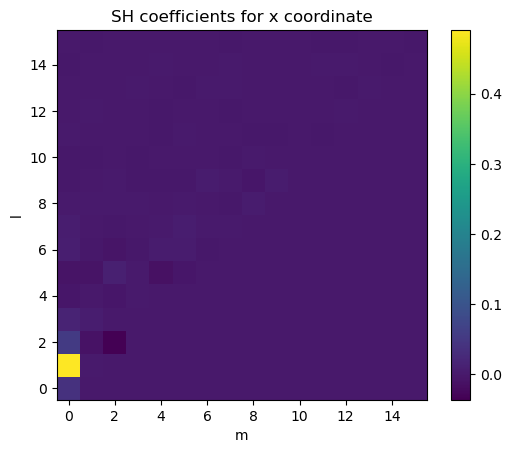

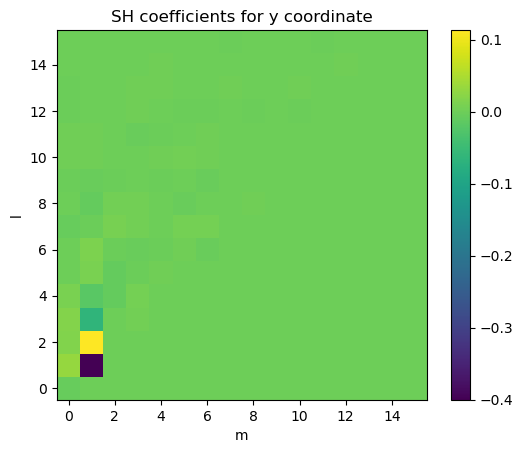

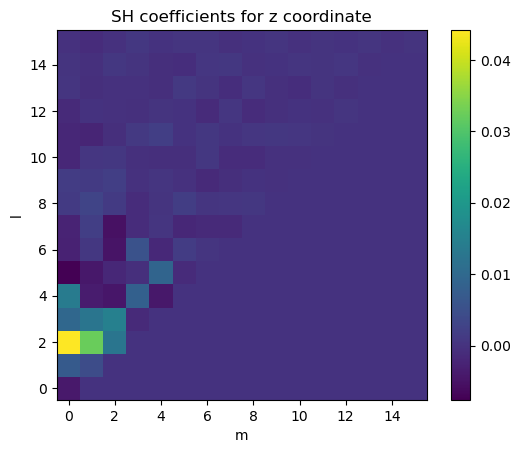

In [59]:
labels = ['x', 'y', 'z']

for i in range(3):

    plt.imshow(m.clms[i][0], origin='lower') 
    plt.xlabel('m')
    plt.ylabel('l')
    plt.colorbar()
    plt.title(f'SH coefficients for {labels[i]} coordinate')
    plt.show() 

In [28]:
import pyshtools as pysh

approximations = [] 
for cutoff in [2, 3, 4, 5, 6, 8, 10, 15]: 
    points = [] 
    for i in range(3): 
        # Expand the SH coefficients for each coordinate 
        clm = m.clms[i][:, :cutoff, :cutoff]  # Get the SH coefficients up to the specified cutoff
        sh = pysh.SHCoeffs.from_array(clm)

        lat, lon = utils.sph2latlon(m.coors[:,0], m.coors[:, 1]) 

        a = sh.expand(lat=lat, lon=lon) 
        points.append(a)
    approximations.append(np.array(points))

approximations = np.array(approximations)


In [29]:
print(approximations.shape)  # (5, 3, 1000)

(8, 3, 19123)


In [31]:
for points in approximations: 
    plot(points.T, m.f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0381417…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1676430…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1444230…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1450993…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1487004…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1607124…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1501939…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1444502…

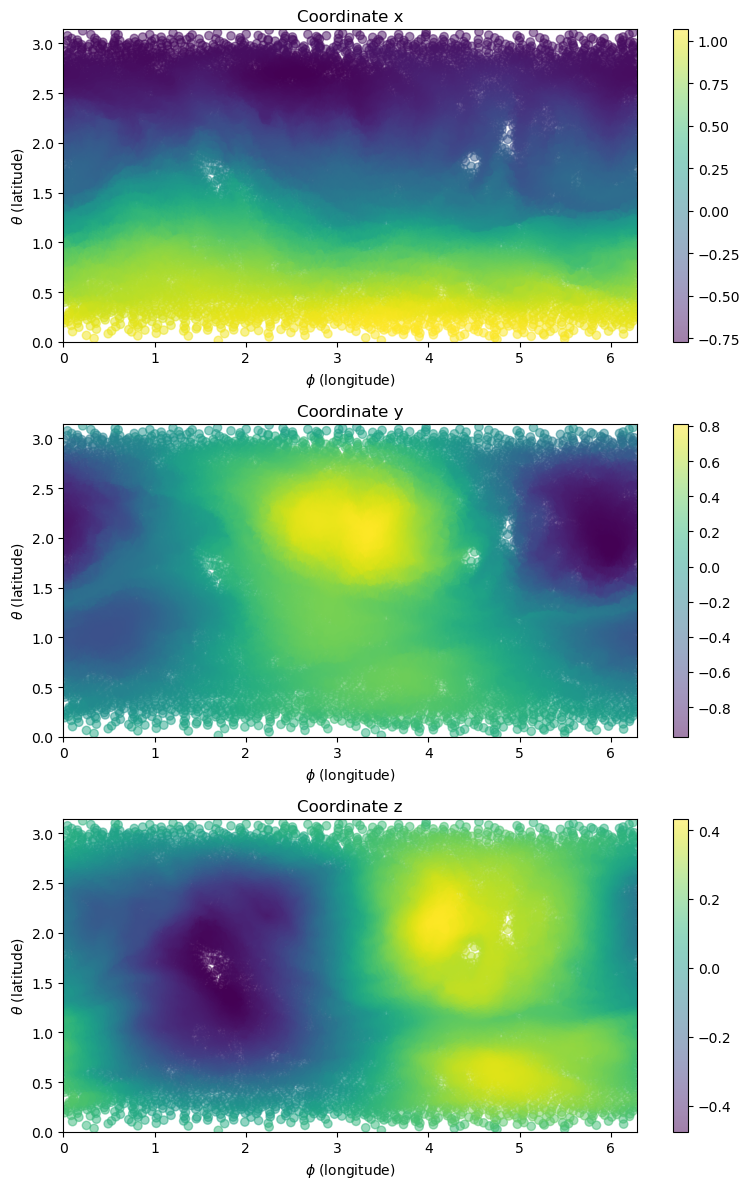

In [50]:
points = approximations[-1]

titles = ['x', 'y', 'z']

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

for i in range(3):
    scatter = axes[i].scatter(m.coors[:, 1], m.coors[:, 0], c=m.v[:, i], alpha=0.5)
    axes[i].set_title(f'Coordinate {titles[i]}')
    axes[i].set_xlim([0, 2*np.pi])
    axes[i].set_ylim([0, np.pi])
    axes[i].set_xlabel(r'$\phi$ (longitude)')
    axes[i].set_ylabel(r'$\theta$ (latitude)')
    plt.colorbar(scatter, ax=axes[i])

plt.tight_layout()
plt.show()

In [32]:
spectrums = [] 
for i in range(3): 
    # Expand the SH coefficients for each coordinate 
    clm = m.clms[i]
    sh = pysh.SHCoeffs.from_array(clm)

    spectrums.append(sh.spectrum())

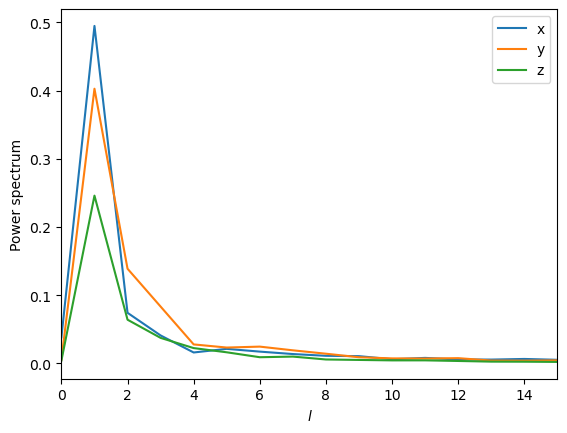

In [39]:
plt.plot(np.sqrt(np.array(spectrums).T), label=['x', 'y', 'z'])
plt.xlabel(r'$l$')
plt.xlim([0, 15])
plt.ylabel('Power spectrum')
plt.legend()
plt.show()  